- # Installation

In [1]:
pip install -q git+https://github.com/BartolomeoF/nDGPemu.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


- # Import libraries and suppress warnings

In [2]:
from nDGPemu import BoostPredictor, test_predict
import numpy as np
import matplotlib.pyplot as plt
from pkg_resources import resource_stream
import warnings

# set matplotlib style
plt.style.use(resource_stream('nDGPemu','cache/my_style.ini').name)

# Suppress all warnings, including deprecation and future warnings
warnings.simplefilter("ignore", category=DeprecationWarning)
warnings.simplefilter("ignore", category=UserWarning)
warnings.simplefilter("ignore", category=FutureWarning)

- # Load nDGP emulator

In [3]:
model = BoostPredictor()

Loading model and related data


- # Test model functionality

In [4]:
# check it is working as expected
test_predict(model)

All tests passed successfully.


- # Estimate boost factor for example parameters and plot results (Define parameters and predict)

In [5]:
# Define parameters
cosmo_params = {'Om':0.32,
                'ns':0.96,
                'As':2.1e-9,
                'h':0.67,
                'Ob':0.048}

H0rc = 1
z = 0.507

# Get boost for training k values
Bk = model.predict(H0rc,z,cosmo_params)
k_vals = model.k_vals

- # Plot $BnDGP$ vs $k$

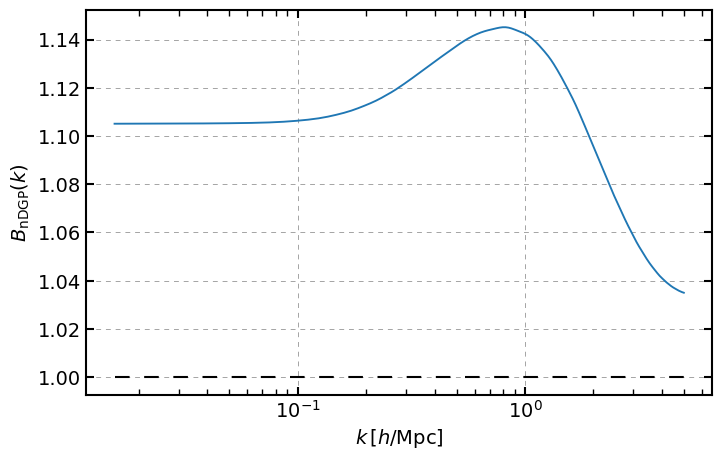

In [6]:
plt.semilogx(k_vals, Bk)
plt.xlabel(r'$k \, [h/{\rm Mpc}]$')
plt.ylabel(r'$B_{\rm nDGP}(k)$')
plt.hlines(1,k_vals.min(),k_vals.max(), 'k','--', lw=1.5);

### *The emulator is capable of generating predictions for arbitrary values of the wavenumber $k$ within the interpolation range. The procedure for achieving this is outlined below.*


- # Predict boost for custom k

In [7]:
# Get boost for custom k values
k_custom = np.logspace(-1.5, 0.5, 10)
Bk_custom = model.predict(H0rc,z,cosmo_params, k_out=k_custom)

- # Compare training and custom k

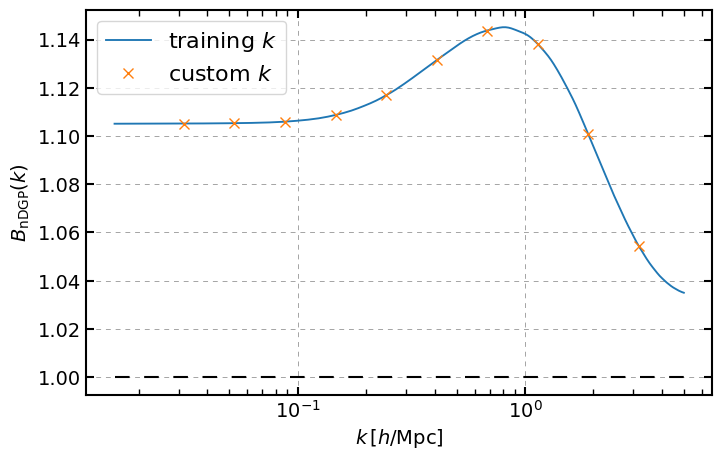

In [8]:
plt.semilogx(k_vals, Bk, label='training $k$')
plt.semilogx(k_custom, Bk_custom, 'x', ms=7, label='custom $k$')
plt.xlabel(r'$k \, [h/{\rm Mpc}]$')
plt.ylabel(r'$B_{\rm nDGP}(k)$')
plt.hlines(1,k_vals.min(),k_vals.max(), 'k','--', lw=1.5);
plt.legend();

### *The emulator is capable of extrapolating beyond the range of the wavenumber $k$. This can be achieved by utilizing the "ext" argument. It is important to note that for $k > k_{\text{max}}$, the results may be unreliable. However, for $k < k_{\text{min}}$, the extrapolated values are expected to align closely with the linear predictions.*

- # Predict boost for extended k

In [9]:
# Get boost for custom k values
k_ext = np.logspace(-2, 1, 30)
Bk_ext = model.predict(H0rc,z,cosmo_params, k_out=k_ext, ext=0)

- # Compare k ranges for boost

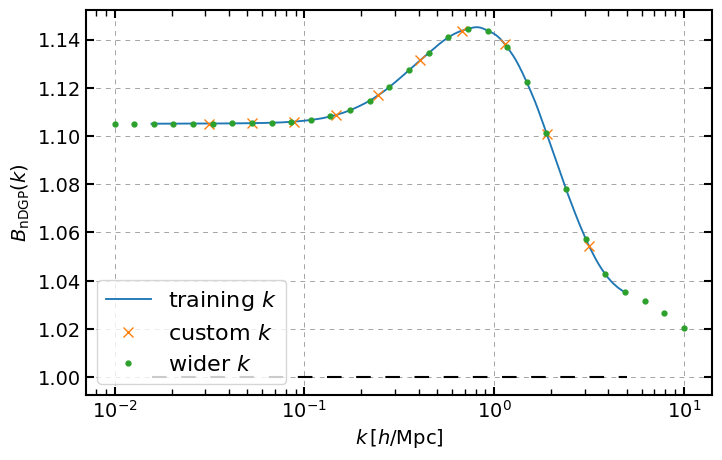

In [10]:
plt.semilogx(k_vals, Bk, label='training $k$')
plt.semilogx(k_custom, Bk_custom, 'x', ms=7, label='custom $k$')
plt.semilogx(k_ext, Bk_ext, '.', ms=7, label='wider $k$')
plt.xlabel(r'$k \, [h/{\rm Mpc}]$')
plt.ylabel(r'$B_{\rm nDGP}(k)$')
plt.hlines(1,k_vals.min(),k_vals.max(), 'k','--', lw=1.5);
plt.legend();